In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")  # 0 = malignant, 1 = benign

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:", dict(zip(data.target_names, [0, 1])))
X.head()

Feature matrix shape: (569, 30)
Target shape: (569,)

Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Class distribution (0 = malignant, 1 = benign):
diagnosis
0    212
1    357

Benign proportion: 0.627


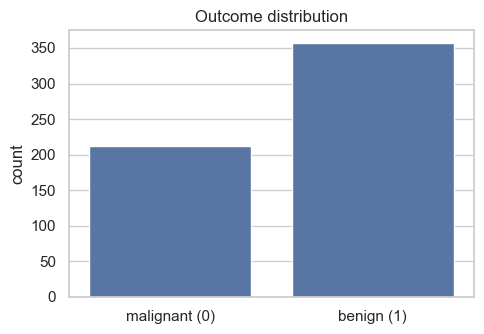

In [3]:
# Class balance
counts = y.value_counts().sort_index()
print("Class distribution (0 = malignant, 1 = benign):")
print(counts.to_string())
print(f"\nBenign proportion: {y.mean():.3f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["malignant (0)", "benign (1)"], y=counts.values, ax=ax)
ax.set_title("Outcome distribution")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

In [4]:
# Quick statistical summary of a few representative features
X[["mean radius", "mean texture", "mean area", "worst concave points"]].describe()

,mean radius,mean texture,mean area,worst concave points
count,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,654.889104,0.114606
std,3.524049,4.301036,351.914129,0.065732
min,6.981000,9.710000,143.500000,0.000000
25%,11.700000,16.170000,420.300000,0.064930
50%,13.370000,18.840000,551.100000,0.099930
75%,15.780000,21.800000,782.700000,0.161400
max,28.110000,39.280000,2501.000000,0.291000


Top 10 features by |correlation| with diagnosis:
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610


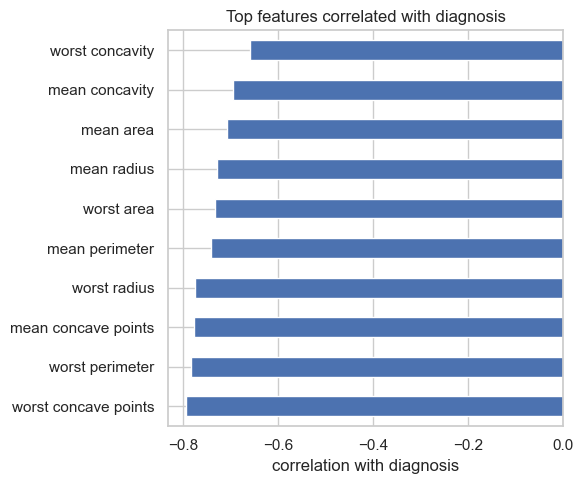

In [5]:
# Correlation of features with the outcome (top absolute correlations)
corr_with_target = (
    pd.concat([X, y], axis=1).corr()["diagnosis"]
    .drop("diagnosis").sort_values(key=np.abs, ascending=False)
)
print("Top 10 features by |correlation| with diagnosis:")
print(corr_with_target.head(10).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
corr_with_target.head(10).sort_values().plot.barh(ax=ax)
ax.set_title("Top features correlated with diagnosis")
ax.set_xlabel("correlation with diagnosis")
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)         # apply same transform to TEST

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 426
Testing samples:  143


In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
}

# Train each model and collect continuous scores on the test set
scores = {}   # raw regression output (≈ probability of benign)
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    scores[name] = model.predict(X_test_scaled)
    print(f"Trained: {name}")

Trained: Linear Regression
Trained: Decision Tree
Trained: Random Forest


In [8]:
rows = []
for name, y_score in scores.items():
    rows.append({
        "Model": name,
        "R2": r2_score(y_test, y_score),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_score)),
        "MAE": mean_absolute_error(y_test, y_score),
    })

regression_results = pd.DataFrame(rows).set_index("Model").round(4)
regression_results

,R2,RMSE,MAE
Model,,,
Linear Regression,0.7255,0.2530,0.2044
Decision Tree,0.7633,0.2350,0.0648
Random Forest,0.8530,0.1852,0.0785


In [9]:
THRESHOLD = 0.5
proba = {name: np.clip(s, 0, 1) for name, s in scores.items()}     # for ROC
preds = {name: (p >= THRESHOLD).astype(int) for name, p in proba.items()}

class_rows = []
for name, y_pred in preds.items():
    class_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, proba[name]),
    })

classification_results = pd.DataFrame(class_rows).set_index("Model").round(4)
classification_results

,Accuracy,ROC AUC
Model,,
Linear Regression,0.9510,0.9943
Decision Tree,0.9441,0.9384
Random Forest,0.9510,0.9919


In [10]:
# Detailed per-class report for the best model (by ROC AUC)
best_model = classification_results["ROC AUC"].idxmax()
print(f"Detailed classification report for: {best_model}\n")
print(classification_report(
    y_test, preds[best_model], target_names=["malignant", "benign"]
))

Detailed classification report for: Linear Regression

              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        53
      benign       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



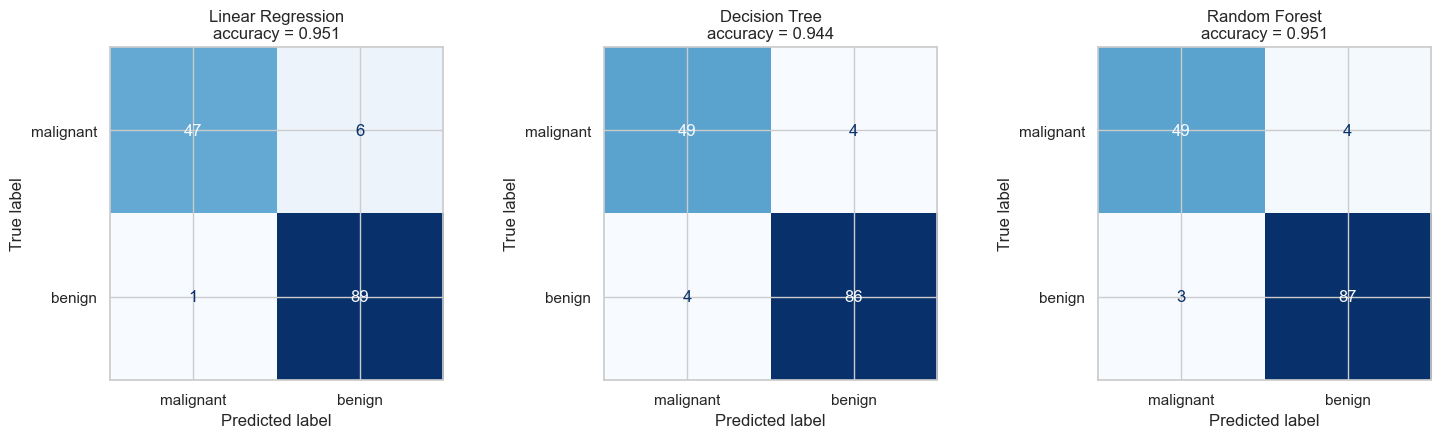

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{name}\naccuracy = {accuracy_score(y_test, y_pred):.3f}")
plt.tight_layout()
plt.show()

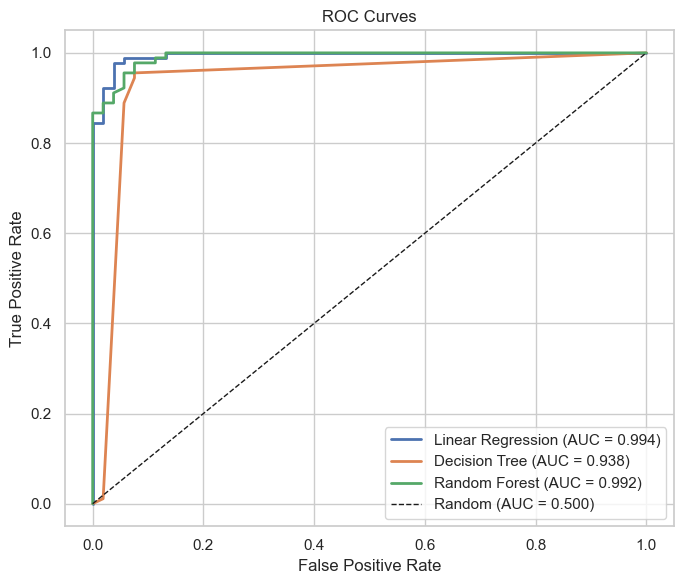

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, p in proba.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

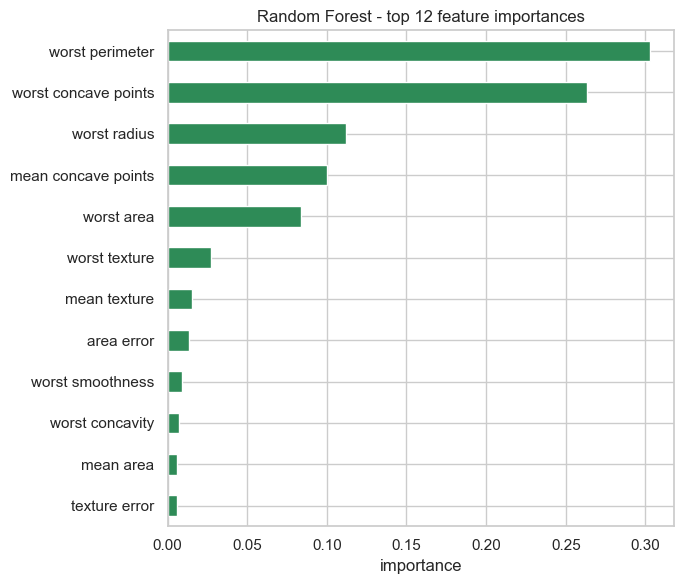

Top 5 most important features:
worst perimeter         0.302800
worst concave points    0.263339
worst radius            0.111962
mean concave points     0.099904
worst area              0.083553


In [13]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
importances.head(12).sort_values().plot.barh(ax=ax, color="seagreen")
ax.set_title("Random Forest - top 12 feature importances")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.head(5).to_string())